# Predicting Optimal Fertilizers (Kaggle PS S5E6) — EDA

**Task:** multi-class classification of `Fertilizer Name` (7 classes) from 8 soil/crop/weather
features. **Metric: MAP@3** — submit up to 3 class names per row, best-first; per-row score is
`1/rank` if the truth is in the top 3, else 0. So we care about *ranking* quality, and the naive
"most-frequent-3-classes" prediction is the floor to beat.

This notebook answers: **class balance · numeric & categorical distributions · feature↔target signal
(per-class means, mutual information, single-feature MAP@3 baselines) · duplicates · train/test drift ·
correlation · NPK structure · comparison with the original UCI dataset (augmentation)**. Figures →
`reports/figures/`; written conclusions → `reports/EDA_FINDINGS.md`.

In [1]:
%matplotlib inline
import pathlib
_root = pathlib.Path.cwd()
if not (_root / "data").exists():   # notebook runs from notebooks/
    _root = _root.parent

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")
RAW = _root / "data" / "raw"
ORIG = _root / "data" / "original" / "Fertilizer Prediction.csv"
FIG = _root / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

TARGET = "Fertilizer Name"
CATEGORICAL = ["Soil Type", "Crop Type"]
# NB: temperature column is misspelled 'Temparature' in the raw data.
NUMERIC = ["Temparature", "Humidity", "Moisture", "Nitrogen", "Potassium", "Phosphorous"]

train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv")
sample = pd.read_csv(RAW / "sample_submission.csv")
print("train:", train.shape, "| test:", test.shape, "| sample_submission:", sample.shape)
print("train columns:", list(train.columns))
CLASSES = sorted(train[TARGET].unique())
print(f"{len(CLASSES)} classes:", CLASSES)

train: (750000, 10) | test: (250000, 9) | sample_submission: (250000, 2)
train columns: ['id', 'Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']
7 classes: ['10-26-26', '14-35-14', '17-17-17', '20-20', '28-28', 'DAP', 'Urea']


## MAP@3 helper + the naive baseline

`mapk3` turns a class-probability matrix (or a fixed ranking) into the MAP@3 score. The **naive
baseline** predicts the 3 globally most-frequent classes for every row — this is the number every model
must beat, and on low-signal Playground data it is often surprisingly close to the best models.

In [2]:
def mapk3(y_true, proba, classes):
    "MAP@3: mean of 1/rank over rows where the true class is in the top-3, else 0."
    classes = list(classes)
    idx = {c: i for i, c in enumerate(classes)}
    yt = np.asarray([idx[y] for y in y_true])
    top3 = np.argsort(-proba, axis=1)[:, :3]
    score = 0.0
    for r in range(3):
        score += (top3[:, r] == yt) / (r + 1.0)
    return float(np.mean(score))

y = train[TARGET].values
counts = train[TARGET].value_counts()
prior = (counts / len(train)).reindex(CLASSES).values          # P(class)
proba_prior = np.tile(prior, (len(train), 1))                   # same ranking for every row
naive_top3 = list(counts.index[:3])
print("class prior (sorted):")
print(counts.to_string())
print("\nnaive top-3 (most frequent):", naive_top3)
print(f"NAIVE-PRIOR OOF-free MAP@3 (train) = {mapk3(y, proba_prior, CLASSES):.5f}")

class prior (sorted):
Fertilizer Name
14-35-14    114436
10-26-26    113887
17-17-17    112453
28-28       111158
20-20       110889
DAP          94860
Urea         92317

naive top-3 (most frequent): ['14-35-14', '10-26-26', '17-17-17']


NAIVE-PRIOR OOF-free MAP@3 (train) = 0.27849


## 1. Class balance
How (im)balanced are the 7 fertilizers? Mild imbalance still matters for the prior ranking.

class share:
 Fertilizer Name
14-35-14    15.26 %
10-26-26    15.18 %
17-17-17    14.99 %
28-28       14.82 %
20-20       14.79 %
DAP         12.65 %
Urea        12.31 %

max/min class ratio: 1.24


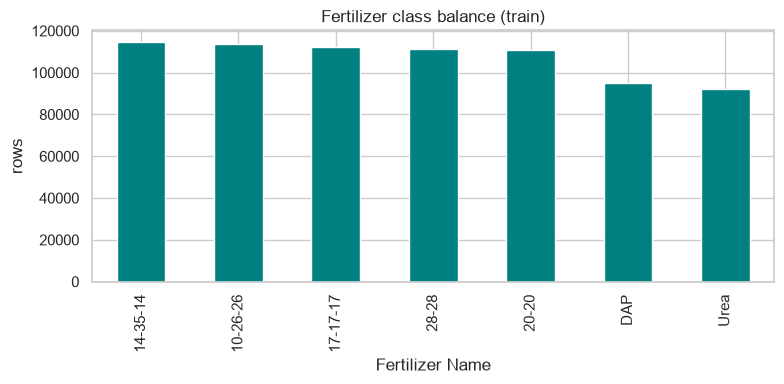

In [3]:
frac = (counts / len(train)).reindex(CLASSES)
print("class share:\n", (frac.sort_values(ascending=False) * 100).round(2).astype(str).add(" %").to_string())
print(f"\nmax/min class ratio: {counts.max()/counts.min():.2f}")
fig, ax = plt.subplots(figsize=(8, 4))
counts.sort_values(ascending=False).plot.bar(ax=ax, color="teal")
ax.set(title="Fertilizer class balance (train)", xlabel="Fertilizer Name", ylabel="rows")
fig.tight_layout(); fig.savefig(FIG / "class_balance.png", dpi=110); plt.show()

## 2. Numeric feature distributions
Temperature/Humidity/Moisture (env) and N/P/K. All are integer-valued; check ranges and shape.

       Temparature   Humidity   Moisture   Nitrogen  Potassium  Phosphorous
count    750000.00  750000.00  750000.00  750000.00  750000.00    750000.00
mean         31.50      61.04      45.18      23.09       9.48        21.07
std           4.03       6.65      11.79      11.22       5.77        12.35
min          25.00      50.00      25.00       4.00       0.00         0.00
25%          28.00      55.00      35.00      13.00       4.00        10.00
50%          32.00      61.00      45.00      23.00       9.00        21.00
75%          35.00      67.00      55.00      33.00      14.00        32.00
max          38.00      72.00      65.00      42.00      19.00        42.00


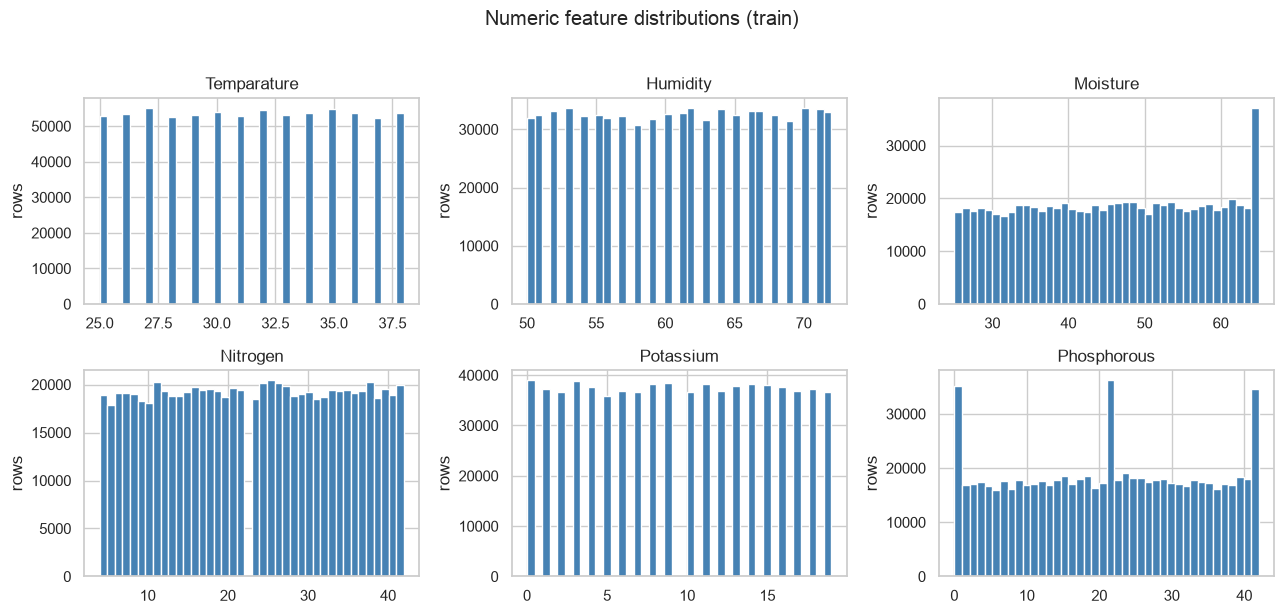

In [4]:
print(train[NUMERIC].describe().round(2).to_string())
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.hist(train[col], bins=40, color="steelblue")
    ax.set(title=col, ylabel="rows")
fig.suptitle("Numeric feature distributions (train)", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "numeric_distributions.png", dpi=110); plt.show()

## 3. Categorical cardinality & frequency
`Soil Type` and `Crop Type` are low-cardinality. Check level frequency and the Soil×Crop grid.

Soil Type: 5 levels
Soil Type
Sandy     20.89 %
Black     20.13 %
Clayey    19.78 %
Red       19.75 %
Loamy     19.45 % 

Crop Type: 11 levels
Crop Type
Paddy          11.43 %
Pulses         10.42 %
Cotton          9.22 %
Tobacco         9.07 %
Wheat           8.88 %
Millets         8.71 %
Barley          8.67 %
Sugarcane       8.57 %
Oil seeds       8.56 %
Maize           8.34 %
Ground Nuts     8.12 % 

Soil×Crop observed combos: 55 (of 55 possible)


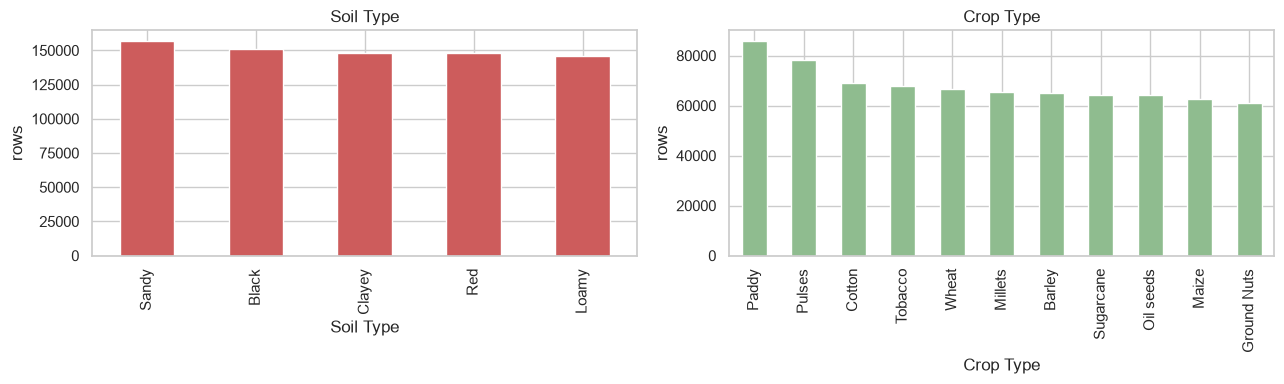

In [5]:
for col in CATEGORICAL:
    vc = train[col].value_counts()
    print(f"{col}: {train[col].nunique()} levels")
    print((vc / len(train) * 100).round(2).astype(str).add(" %").to_string(), "\n")
combo_n = train.groupby(CATEGORICAL, observed=True).size()
print(f"Soil×Crop observed combos: {combo_n.shape[0]} (of {train['Soil Type'].nunique()*train['Crop Type'].nunique()} possible)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train["Soil Type"].value_counts().plot.bar(ax=axes[0], color="indianred", title="Soil Type")
train["Crop Type"].value_counts().plot.bar(ax=axes[1], color="darkseagreen", title="Crop Type")
for a in axes: a.set_ylabel("rows")
fig.tight_layout(); fig.savefig(FIG / "categorical_frequency.png", dpi=110); plt.show()

## 4. Feature ↔ target signal

The crux for a low-signal dataset. Three complementary views:
1. **Per-class numeric means** — do fertilizers separate on N/P/K or env? (heatmap of z-scored means)
2. **Mutual information** `I(feature; target)` for every feature (subsampled for speed).
3. **Single-feature MAP@3 baselines** — rank classes by their conditional frequency given one feature
   (`P(class | feature)`), score MAP@3, and compare with the naive prior. The *lift over the naive
   prior* is the honest signal that feature carries under the competition metric.

/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_8668/1496160647.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  z = (means - means.mean(0)) / means.std(0)
/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_8668/1496160647.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  z = (means - means.mean(0)) / means.std(0)


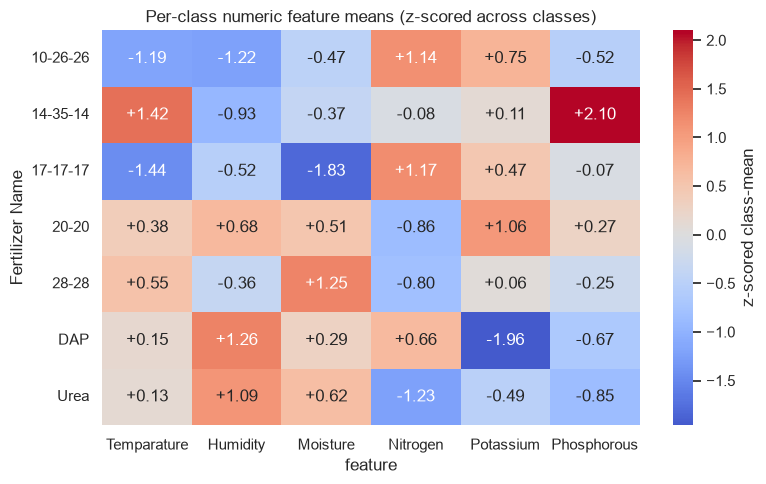

range of z-scored class means per feature (max-min):
Moisture       3.08
Potassium      3.02
Phosphorous    2.95
Temparature    2.86
Humidity       2.48
Nitrogen       2.40


In [6]:
# 4.1 per-class z-scored numeric means
means = train.groupby(TARGET)[NUMERIC].mean()
z = (means - means.mean(0)) / means.std(0)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(z.loc[CLASSES], annot=True, fmt="+.2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "z-scored class-mean"})
ax.set(title="Per-class numeric feature means (z-scored across classes)", xlabel="feature", ylabel=TARGET)
fig.tight_layout(); fig.savefig(FIG / "per_class_means.png", dpi=110); plt.show()
print("range of z-scored class means per feature (max-min):")
print((z.max() - z.min()).round(2).sort_values(ascending=False).to_string())

mutual information I(feature; target)  [nats]:
Moisture       0.00620
Nitrogen       0.00274
Temparature    0.00267
Crop Type      0.00214
Humidity       0.00201
Phosphorous    0.00109
Soil Type      0.00074
Potassium      0.00000


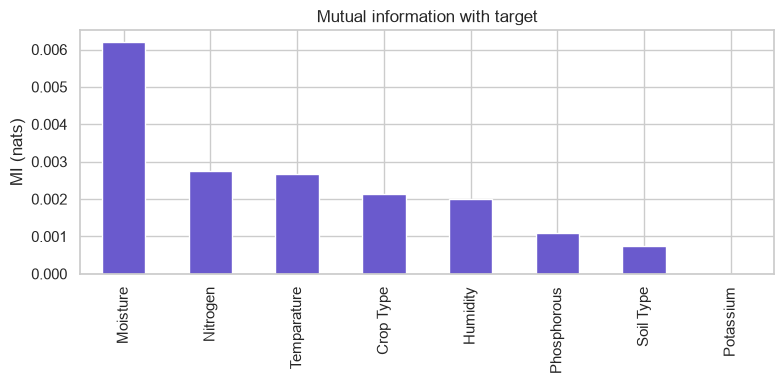

In [7]:
# 4.2 mutual information (subsample for speed; encode categoricals as codes)
rng = np.random.default_rng(42)
sub = rng.choice(len(train), size=min(150_000, len(train)), replace=False)
Xmi = train.iloc[sub].copy()
feat_cols = NUMERIC + CATEGORICAL
Xenc = pd.DataFrame(index=Xmi.index)
discrete = []
for c in feat_cols:
    if c in CATEGORICAL:
        Xenc[c] = Xmi[c].astype("category").cat.codes; discrete.append(True)
    else:
        Xenc[c] = Xmi[c]; discrete.append(False)
mi = mutual_info_classif(Xenc.values, Xmi[TARGET].values, discrete_features=discrete, random_state=42)
mi_s = pd.Series(mi, index=feat_cols).sort_values(ascending=False)
print("mutual information I(feature; target)  [nats]:")
print(mi_s.round(5).to_string())
fig, ax = plt.subplots(figsize=(8, 4)); mi_s.plot.bar(ax=ax, color="slateblue")
ax.set(title="Mutual information with target", ylabel="MI (nats)")
fig.tight_layout(); fig.savefig(FIG / "mutual_information.png", dpi=110); plt.show()

In [8]:
# 4.3 single-feature MAP@3 baselines: rank classes by P(class | feature level/bin)
def single_feature_mapk3(col, bins=None):
    s = train[col]
    key = pd.cut(s, bins=bins, labels=False, include_lowest=True) if bins else s
    # P(class | key) as a lookup, fall back to global prior for unseen keys
    ct = pd.crosstab(key, train[TARGET]).reindex(columns=CLASSES).fillna(0)
    probs = (ct.values + 1e-9)
    probs = probs / probs.sum(1, keepdims=True)
    lut = {k: probs[i] for i, k in enumerate(ct.index)}
    P = np.vstack([lut.get(k, prior) for k in key.values])
    return mapk3(y, P, CLASSES)

rows = [("(naive prior)", mapk3(y, proba_prior, CLASSES))]
for c in CATEGORICAL:
    rows.append((c, single_feature_mapk3(c)))
for c in NUMERIC:
    rows.append((c + " (10 bins)", single_feature_mapk3(c, bins=10)))
# joint Soil×Crop
sc = train["Soil Type"].astype(str) + " | " + train["Crop Type"].astype(str)
ct = pd.crosstab(sc, train[TARGET]).reindex(columns=CLASSES).fillna(0).values + 1e-9
ct = ct / ct.sum(1, keepdims=True)
lut = {k: ct[i] for i, k in enumerate(pd.crosstab(sc, train[TARGET]).index)}
P = np.vstack([lut[k] for k in sc.values])
rows.append(("Soil×Crop (joint)", mapk3(y, P, CLASSES)))

res = pd.DataFrame(rows, columns=["feature", "train MAP@3"]).sort_values("train MAP@3", ascending=False)
res["lift vs prior"] = res["train MAP@3"] - rows[0][1]
print(res.to_string(index=False))
print("\nNOTE: these are in-sample (train) MAP@3 — upper bounds; real OOF will be a touch lower.")

              feature  train MAP@3  lift vs prior
    Soil×Crop (joint)     0.289652       0.011167
   Moisture (10 bins)     0.285096       0.006610
            Crop Type     0.283985       0.005500
  Potassium (10 bins)     0.283408       0.004922
Phosphorous (10 bins)     0.283114       0.004628
   Humidity (10 bins)     0.282816       0.004331
Temparature (10 bins)     0.282510       0.004025
   Nitrogen (10 bins)     0.282393       0.003908
            Soil Type     0.281398       0.002913
        (naive prior)     0.278485       0.000000

NOTE: these are in-sample (train) MAP@3 — upper bounds; real OOF will be a touch lower.


## 5. Duplicates & data quality
Exact duplicate feature rows, and feature rows with *conflicting* fertilizer labels (a signal ceiling).

In [9]:
feat_cols = NUMERIC + CATEGORICAL
dup_feats = train.duplicated(subset=feat_cols).sum()
print(f"exact-duplicate feature rows (any label): {dup_feats} ({dup_feats/len(train)*100:.2f}%)")
# rows whose full feature vector maps to >1 distinct fertilizer -> irreducible ambiguity
grp = train.groupby(feat_cols, observed=True)[TARGET].nunique()
ambig_groups = int((grp > 1).sum())
ambig_rows = int(train.groupby(feat_cols, observed=True)[TARGET].transform("nunique").gt(1).sum())
print(f"distinct feature vectors: {grp.shape[0]:,}")
print(f"feature vectors mapping to >1 fertilizer: {ambig_groups:,} groups, covering {ambig_rows:,} rows ({ambig_rows/len(train)*100:.1f}%)")
print("nulls — train:", int(train.isna().sum().sum()), "| test:", int(test.isna().sum().sum()))

exact-duplicate feature rows (any label): 0 (0.00%)


distinct feature vectors: 750,000
feature vectors mapping to >1 fertilizer: 0 groups, covering 0 rows (0.0%)
nulls — train: 0 | test: 0


## 6. Train vs test drift
Test labels are hidden, so compare feature distributions (KS for numeric, share deltas for categorical).

numeric KS train-vs-test p-values:
  Temparature    p=0.426
  Humidity       p=0.779
  Moisture       p=1.000
  Nitrogen       p=0.128
  Potassium      p=0.908
  Phosphorous    p=0.048
features with KS p<0.01: 0 / 6
Soil Type: max |share delta| train-vs-test = 0.133 pp
Crop Type: max |share delta| train-vs-test = 0.148 pp


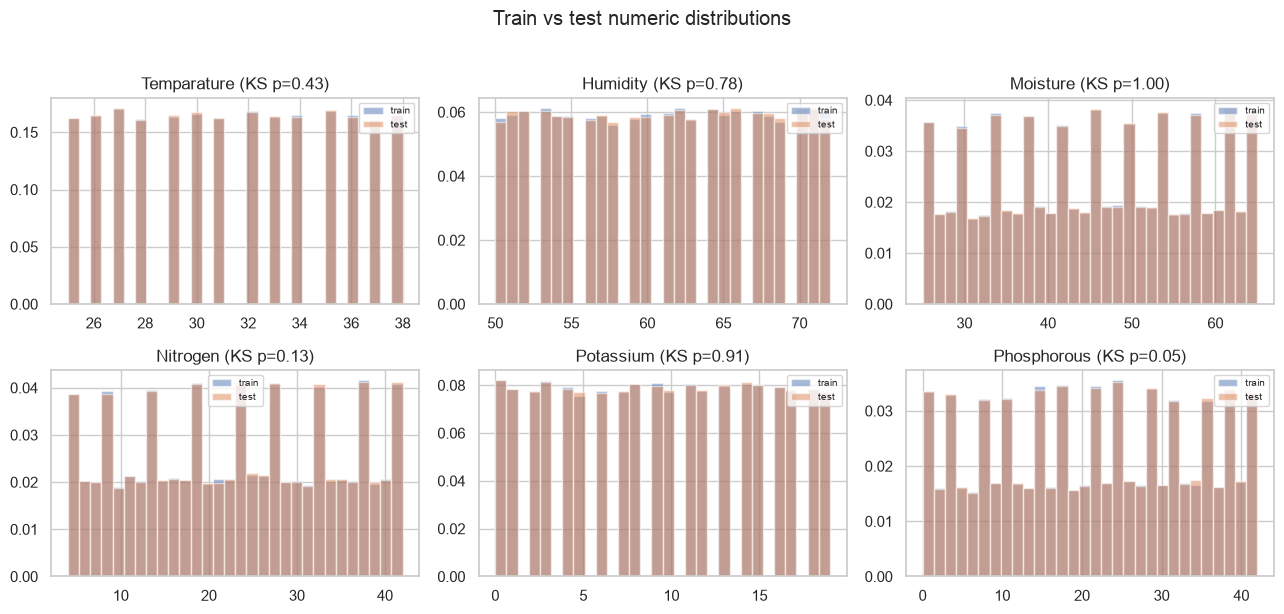

In [10]:
ks = {c: stats.ks_2samp(train[c], test[c]).pvalue for c in NUMERIC}
print("numeric KS train-vs-test p-values:")
for c, p in ks.items(): print(f"  {c:14s} p={p:.3f}")
print("features with KS p<0.01:", sum(p < 0.01 for p in ks.values()), "/", len(ks))
for c in CATEGORICAL:
    d = (train[c].value_counts(normalize=True) - test[c].value_counts(normalize=True)).abs().max()
    print(f"{c}: max |share delta| train-vs-test = {d*100:.3f} pp")

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.hist(train[col], bins=30, alpha=0.5, density=True, label="train")
    ax.hist(test[col], bins=30, alpha=0.5, density=True, label="test")
    ax.set(title=f"{col} (KS p={ks[col]:.2f})"); ax.legend(fontsize=7)
fig.suptitle("Train vs test numeric distributions", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "train_test_drift.png", dpi=110); plt.show()

## 7. Correlation & NPK structure
Linear correlation among numeric features (trees exploit interactions, but redundancy is worth knowing).

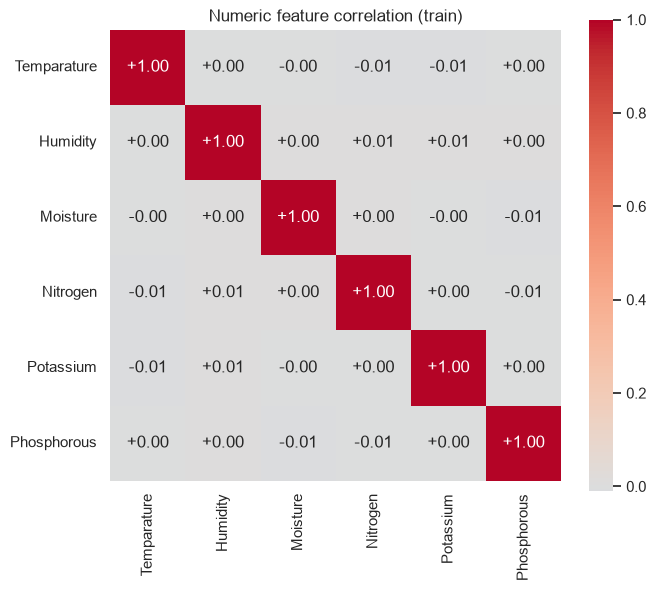

max |off-diagonal| correlation: 0.01


In [11]:
corr = train[NUMERIC].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set(title="Numeric feature correlation (train)")
fig.tight_layout(); fig.savefig(FIG / "numeric_correlation.png", dpi=110); plt.show()
print("max |off-diagonal| correlation:",
      round(corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max(), 3))

## 8. Original UCI dataset comparison (augmentation)

The competition data was synthesized from the small **UCI "Fertilizer Prediction"** dataset. Compare
schema, class/level overlap, and numeric distribution shift to decide whether appending the original
rows to training (Step 4) is worth testing.

In [12]:
orig = pd.read_csv(ORIG)
orig.columns = [c.strip() for c in orig.columns]           # 'Humidity ' has a trailing space
print("original shape:", orig.shape, "| columns:", list(orig.columns))
print("class overlap — only in orig:", set(orig[TARGET]) - set(CLASSES),
      "| only in comp:", set(CLASSES) - set(orig[TARGET]))
for c in CATEGORICAL:
    print(f"{c}: orig-only={set(orig[c]) - set(train[c])} comp-only={set(train[c]) - set(orig[c])}")
print("\noriginal class balance:\n", orig[TARGET].value_counts().to_string())
print("\nnumeric range comparison (min/max):")
cmp = pd.DataFrame({
    "orig_min": orig[NUMERIC].min(), "orig_max": orig[NUMERIC].max(),
    "comp_min": train[NUMERIC].min(), "comp_max": train[NUMERIC].max(),
})
print(cmp.to_string())

original shape: (99, 9) | columns: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']
class overlap — only in orig: set() | only in comp: set()
Soil Type: orig-only=set() comp-only=set()


Crop Type: orig-only=set() comp-only=set()

original class balance:
 Fertilizer Name
Urea        22
DAP         18
28-28       17
14-35-14    14
20-20       14
17-17-17     7
10-26-26     7

numeric range comparison (min/max):
             orig_min  orig_max  comp_min  comp_max
Temparature        25        38        25        38
Humidity           50        72        50        72
Moisture           25        65        25        65
Nitrogen            4        42         4        42
Potassium           0        19         0        19
Phosphorous         0        42         0        42


## Summary
Key numbers and modeling implications are written up in **`reports/EDA_FINDINGS.md`**.